# Разведочный анализ данных (EDA)

**Визуальный анализ телеметрии: тренды, сезонность, выбросы, пропуски**


In [1]:
# Базовые импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Загрузка
data_train = pd.read_csv('data_train.csv', parse_dates=['datetime'], index_col='datetime')
data_train

,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
datetime,,,,,,,,,,,,,,,,
2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.471920,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.471920,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.471920,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.471920,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.471920,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-10-07 19:54:00,0.716126,0.409256,0.316542,0.604638,0.919214,0.800036,0.741821,0.465318,0.464397,0.728682,0.728682,0.728682,NaN,NaN,NaN,NaN
2019-10-07 19:55:00,0.710918,0.408751,0.316832,0.607323,0.919214,0.800615,0.742358,0.465318,0.464397,0.728682,0.728682,0.728682,NaN,NaN,NaN,NaN
2019-10-07 19:56:00,0.704842,0.409621,0.316832,0.607274,0.919214,0.800615,0.742358,0.465318,0.462082,0.728682,0.728682,0.728682,NaN,NaN,NaN,NaN


In [ ]:
target_train = pd.read_csv('target_train.csv', parse_dates=['Дата'], index_col='Дата')
target_train

,target
Дата,
2019-03-13 17:00:00,0.123711
2019-03-13 21:00:00,0.319588
2019-03-14 01:00:00,0.255155
2019-03-14 05:00:00,0.319588
2019-03-14 09:00:00,0.159794
...,...
2019-10-07 13:00:00,0.128866
2019-10-07 15:00:00,0.170103
2019-10-07 17:00:00,0.167526


In [ ]:
# Объединим для удобства анализа пропусков и корреляций,
# используя ближайшие значения телеметрии к моменту замера
df_train = pd.merge_asof(target_train.sort_index(), data_train.sort_index(),
                         left_index=True, right_index=True, direction='backward')

print(f"Размер обучающей выборки телеметрии: {data_train.shape}")
print(f"Количество лабораторных замеров: {target_train.shape[0]}")

Размер обучающей выборки телеметрии: (319546, 16)
Количество лабораторных замеров: 1773


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1773 entries, 2019-03-13 17:00:00 to 2019-10-07 21:00:00
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   target        1773 non-null   float64
 1   telemetry_0   1773 non-null   float64
 2   telemetry_1   1773 non-null   float64
 3   telemetry_2   1773 non-null   float64
 4   telemetry_3   1773 non-null   float64
 5   telemetry_4   1772 non-null   float64
 6   telemetry_5   1773 non-null   float64
 7   telemetry_6   1773 non-null   float64
 8   telemetry_7   1773 non-null   float64
 9   telemetry_8   1773 non-null   float64
 10  telemetry_9   1773 non-null   float64
 11  telemetry_10  1773 non-null   float64
 12  telemetry_11  1773 non-null   float64
 13  telemetry_12  5 non-null      float64
 14  telemetry_13  5 non-null      float64
 15  telemetry_14  5 non-null      float64
 16  telemetry_15  5 non-null      float64
dtypes: float64(17)
memory usage: 249.3 

Пропуски в данных по столбцам:
telemetry_0         17
telemetry_1         16
telemetry_2         16
telemetry_3         16
telemetry_4        133
telemetry_5         17
telemetry_6         16
telemetry_7         16
telemetry_8         16
telemetry_9         16
telemetry_10        16
telemetry_11        16
telemetry_12    317448
telemetry_13    317448
telemetry_14    317448
telemetry_15    317448
dtype: int64


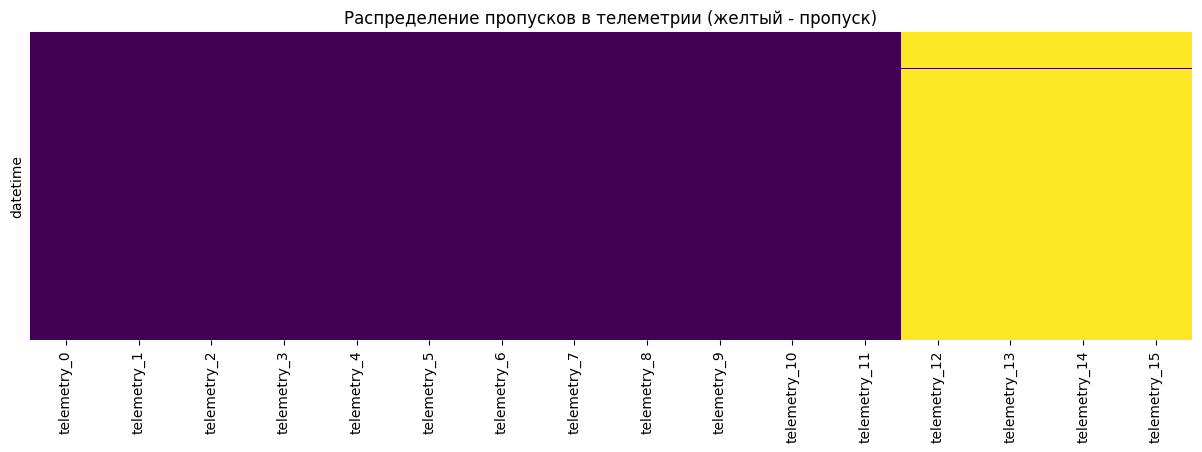

In [ ]:
missing_values = data_train.isnull().sum()
if missing_values.sum() > 0:
    print("Пропуски в данных по столбцам:")
    print(missing_values[missing_values > 0])

    # Визуализация пропусков во времени
    plt.figure(figsize=(15, 4))
    sns.heatmap(data_train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Распределение пропусков в телеметрии (желтый - пропуск)")
    plt.show()
else:
    print("Явных пропусков (NaN) в телеметрии не обнаружено.")

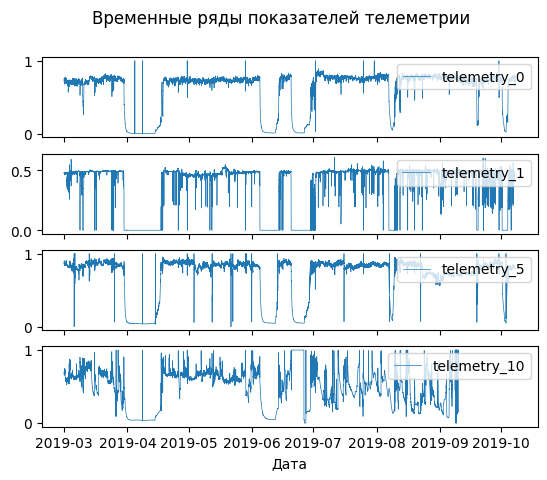

In [ ]:
# Визуализируем первые 4 датчика и таргет для поиска глобальных трендов
cols_to_plot = ['telemetry_0', 'telemetry_1', 'telemetry_5', 'telemetry_10']

fig, axes = plt.subplots(len(cols_to_plot), 1, sharex=True)
for i, col in enumerate(cols_to_plot):
    axes[i].plot(data_train.index, data_train[col], label=col, linewidth=0.5)
    axes[i].legend(loc='upper right')

plt.xlabel("Дата")
plt.suptitle("Временные ряды показателей телеметрии")
plt.show()

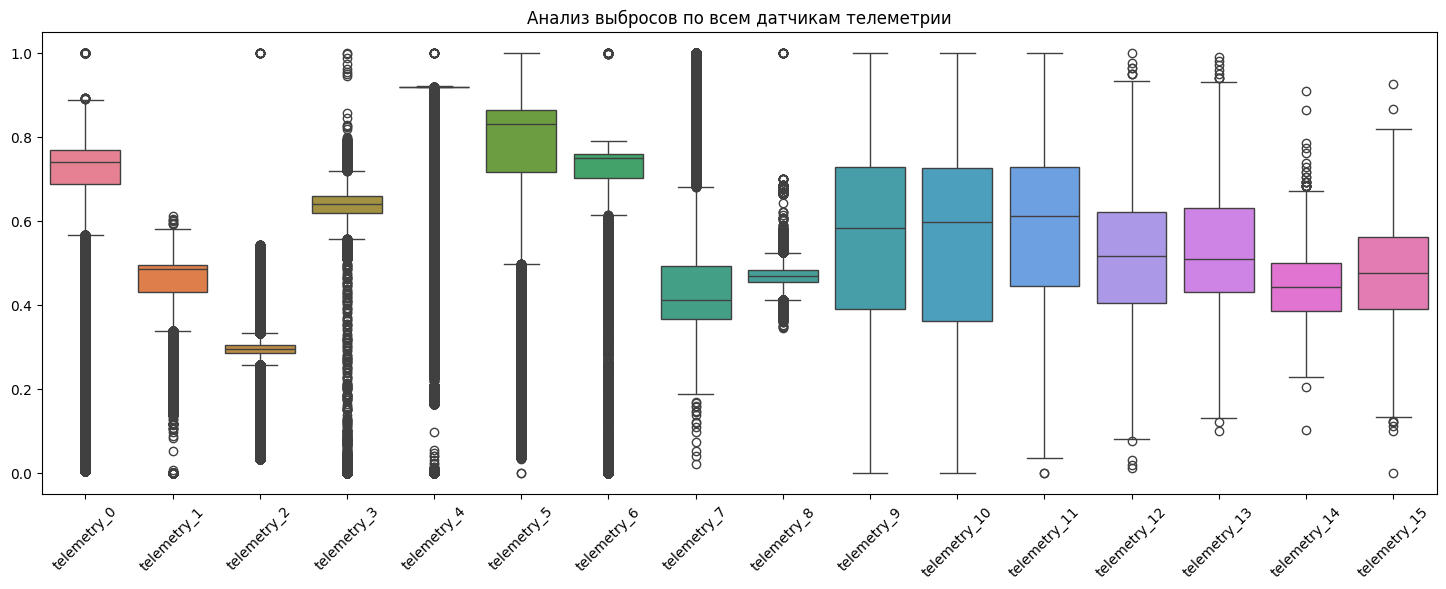

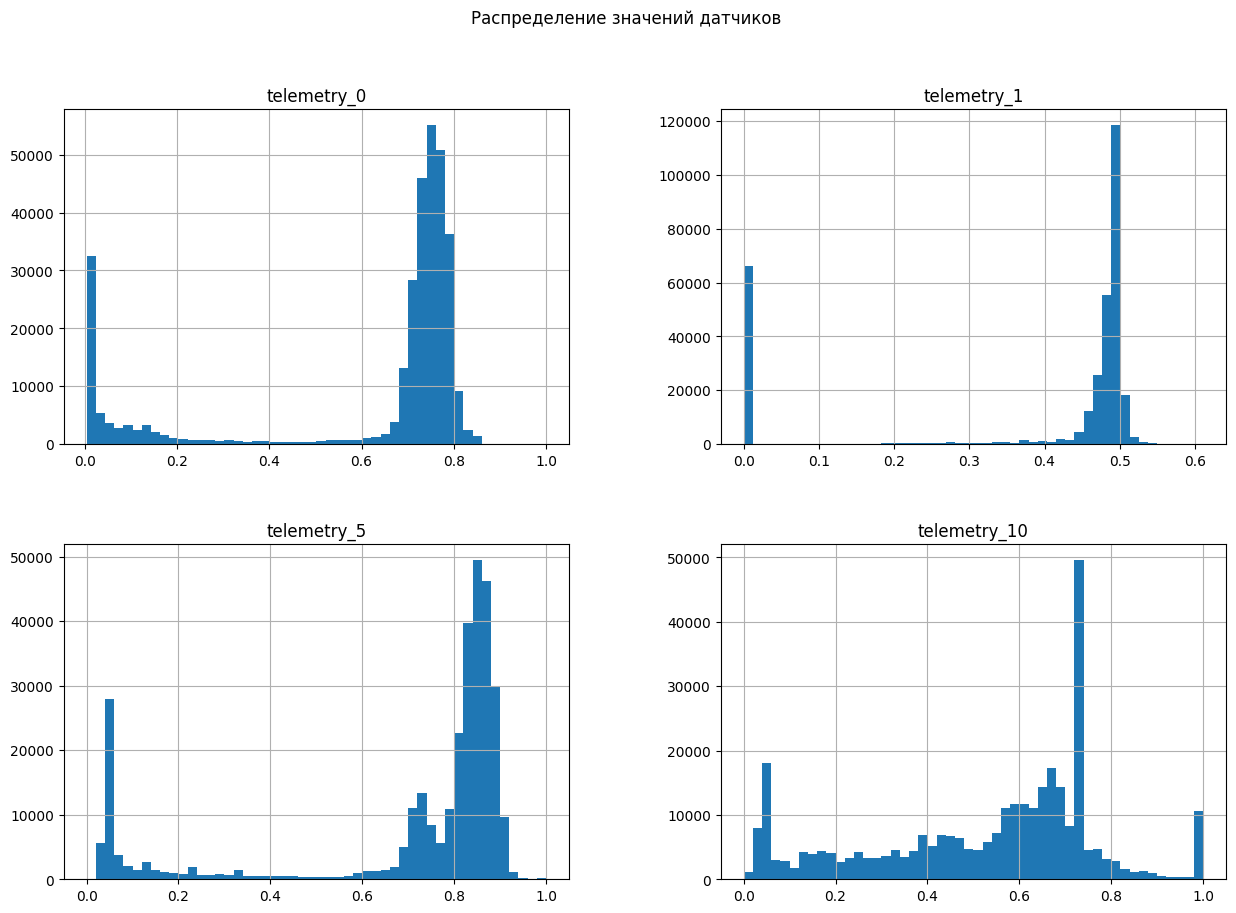

In [ ]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=data_train)
plt.title("Анализ выбросов по всем датчикам телеметрии")
plt.xticks(rotation=45)
plt.show()

# Гистограммы распределения
data_train[cols_to_plot].hist(bins=50, figsize=(15, 10))
plt.suptitle("Распределение значений датчиков")
plt.show()

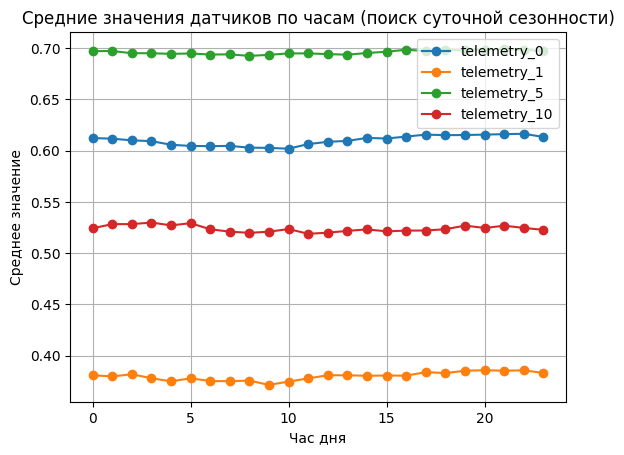

In [ ]:
# Посмотрим на средние значения по часам (суточный цикл)
data_train['hour'] = data_train.index.hour
hourly_avg = data_train.groupby('hour')[cols_to_plot].mean()

hourly_avg.plot(marker='o')
plt.title("Средние значения датчиков по часам (поиск суточной сезонности)")
plt.xlabel("Час дня")
plt.ylabel("Среднее значение")
plt.grid(True)
plt.show()



Выводы:

- Целевая переменная имеет бимодальное распределение, возможны два режима работы печи.

- Интервалы между замерами в основном 120 минут (2 часа), реже 240 минут. Минимальный интервал – 60 минут.

- Почти все замеры имеют точное совпадение по времени с минутной телеметрией (благодаря округлению).

- Пробы обычно берутся в начале часа (минута 0) или в 15/45 минутах.

**Исследование целевой переменной: распределение, частоту, задержки относительно телеметрии**

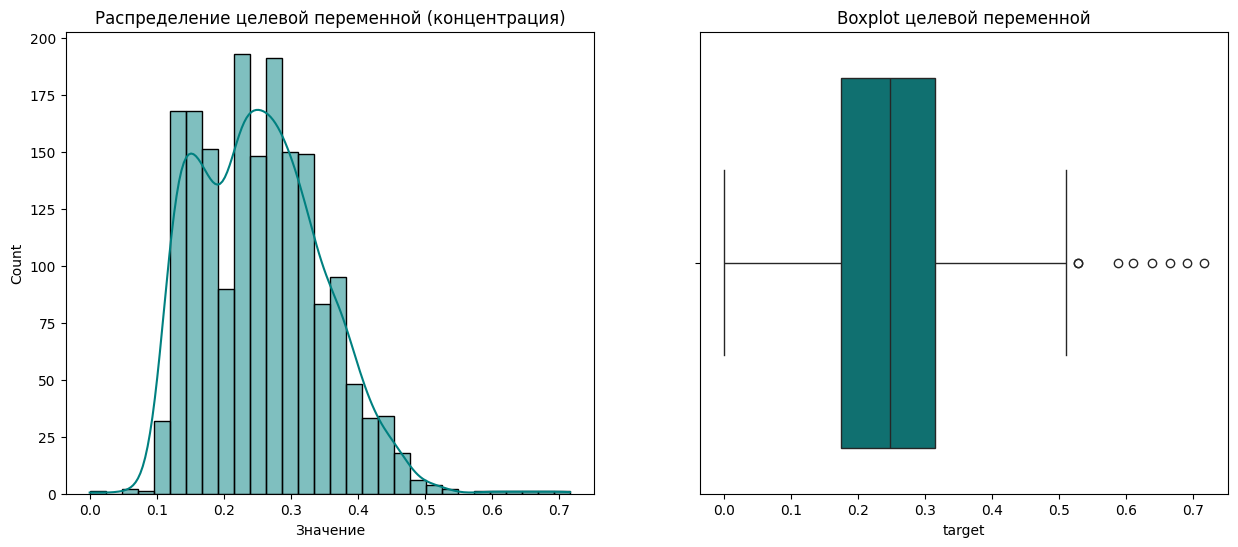

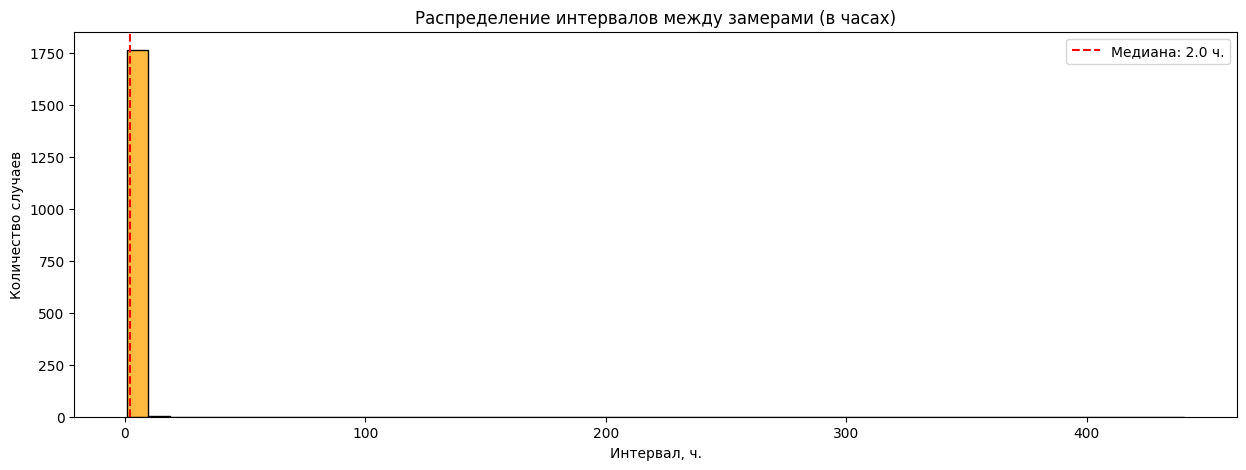

Замеры, для которых есть точное совпадение по времени в телеметрии: 1772 из 1773

Пропусков в целевой переменной: 0

Статистика интервалов между замерами:
count    1772.000000
mean        2.819413
std        13.068138
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max       440.500000
Name: time_diff, dtype: float64


In [ ]:
# Рассчитаем интервалы между замерами в часах
target_train_sorted = target_train.sort_index()
target_train_sorted['time_diff'] = target_train_sorted.index.to_series().diff().dt.total_seconds() / 3600

# Визуализация распределения целевой переменной
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(target_train['target'], kde=True, bins=30, color='teal')
plt.title("Распределение целевой переменной (концентрация)")
plt.xlabel("Значение")

plt.subplot(1, 2, 2)
sns.boxplot(x=target_train['target'], color='teal')
plt.title("Boxplot целевой переменной")
plt.show()

# Анализ частоты замеров
plt.figure(figsize=(15, 5))
sns.histplot(target_train_sorted['time_diff'].dropna(), bins=50, color='orange')
plt.title("Распределение интервалов между замерами (в часах)")
plt.xlabel("Интервал, ч.")
plt.ylabel("Количество случаев")
plt.axvline(target_train_sorted['time_diff'].median(), color='red', linestyle='--',
            label=f'Медиана: {target_train_sorted["time_diff"].median():.1f} ч.')
plt.legend()
plt.show()

# Анализ задержки (Lag Analysis)
# По условию задержка составляет 10-15 минут.
# Проверим, есть ли в телеметрии данные непосредственно в моменты, указанные в target_train
common_times = target_train.index.isin(data_train.index)
print(f"Замеры, для которых есть точное совпадение по времени в телеметрии: {common_times.sum()} из {len(target_train)}")

# 4. Проверка пропусков в таргете
print(f"\nПропусков в целевой переменной: {target_train['target'].isnull().sum()}")

# Вывод статистик по времени
print("\nСтатистика интервалов между замерами:")
print(target_train_sorted['time_diff'].describe())

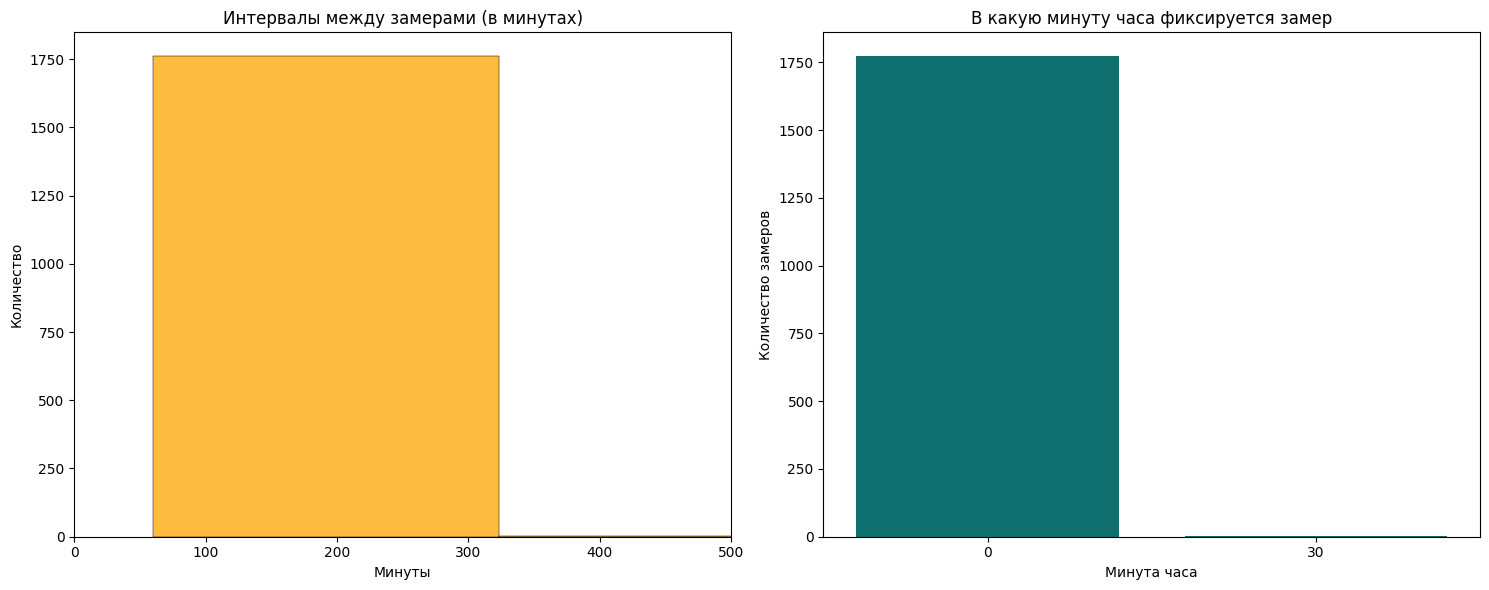

Топ-5 наиболее частых интервалов (в минутах):
time_diff_min
120.0      1570
240.0       184
60.0          4
420.0         2
26430.0       1
Name: count, dtype: int64

Минимальный интервал: 60.0 мин.
Медианный интервал: 120.0 мин.


In [ ]:
# Рассчитаем интервалы между замерами в минутах
target_train_sorted['time_diff_min'] = target_train_sorted.index.to_series().diff().dt.total_seconds() / 60

plt.figure(figsize=(15, 6))

# 1. Распределение интервалов в минутах (ограничим 500 минутами для наглядности основной массы)
plt.subplot(1, 2, 1)
sns.histplot(target_train_sorted['time_diff_min'].dropna(), bins=100, color='orange')
plt.xlim(0, 500)
plt.title("Интервалы между замерами (в минутах)")
plt.xlabel("Минуты")
plt.ylabel("Количество")

# 2. Анализ "минуты замера" (в какую минуту каждого часа берется проба)
plt.subplot(1, 2, 2)
target_train_sorted['minute_of_hour'] = target_train_sorted.index.minute
sns.countplot(x='minute_of_hour', data=target_train_sorted, color='teal')
plt.title("В какую минуту часа фиксируется замер")
plt.xlabel("Минута часа")
plt.ylabel("Количество замеров")

plt.tight_layout()
plt.show()

# Вывод конкретных цифр
print("Топ-5 наиболее частых интервалов (в минутах):")
print(target_train_sorted['time_diff_min'].value_counts().head(5))

print(f"\nМинимальный интервал: {target_train_sorted['time_diff_min'].min()} мин.")
print(f"Медианный интервал: {target_train_sorted['time_diff_min'].median()} мин.")

**Синхронизация двух источников данных (минутная телеметрия + нерегулярные лабораторные замеры) с учётом временной задержки отбора проб**

In [ ]:
# Установка базового лага (в минутах)
# По результатам анализа корреляций и условий задачи
TIME_LAG = 15

# Подготовка таргета: сдвигаем метку времени назад
# Это значит, что результат анализа, полученный в 12:15,
# мы относим к состоянию телеметрии в 12:00
target_train_shifted = target_train.copy()
target_train_shifted.index = target_train_shifted.index - pd.Timedelta(minutes=TIME_LAG)

# Синхронизация через merge_asof
# Мы берем каждый сдвинутый замер и ищем для него ближайшую запись в телеметрии "в прошлом"
# (хотя после сдвига это будет фактически соответствовать моменту забора пробы)
merged_train = pd.merge_asof(
    target_train_shifted.sort_index(),
    data_train.sort_index(),
    left_index=True,
    right_index=True,
    direction='backward'
)

# Очистка признаков, которые мы создавали для анализа (hour, minute_of_hour и т.д.)
# Оставляем только чистую телеметрию и таргет
cols_to_drop = ['time_diff', 'time_diff_min', 'minute_of_hour', 'hour']
merged_train = merged_train.drop(columns=[c for c in cols_to_drop if c in merged_train.columns])

# Обработка константных признаков и полных пропусков
# Удаляем датчики, в которых нет данных или всего одно уникальное значение (они бесполезны для модели)
constant_cols = [col for col in merged_train.columns if merged_train[col].nunique() <= 1]
merged_train = merged_train.drop(columns=constant_cols)

print(f"Синхронизация завершена.")
print(f"Итоговый размер обучающей выборки: {merged_train.shape}")
print(f"Удаленные константные столбцы: {constant_cols}")

# Посмотрим на первые строки синхронизированных данных
merged_train.head()

Синхронизация завершена.
Итоговый размер обучающей выборки: (1773, 13)
Удаленные константные столбцы: ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']


,target,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11
Дата,,,,,,,,,,,,,
2019-03-13 16:45:00,0.123711,0.787016,0.497628,0.309019,0.640194,0.919471,0.878159,0.753513,0.433526,0.474235,0.697826,0.770140,0.648041
2019-03-13 20:45:00,0.319588,0.782386,0.497628,0.301496,0.648751,0.919471,0.851539,0.755444,0.470685,0.476550,0.712567,0.752339,0.629406
2019-03-14 00:45:00,0.255155,0.788462,0.497521,0.300339,0.633713,0.919471,0.876134,0.753513,0.443848,0.474235,0.705614,0.760683,0.642756
2019-03-14 04:45:00,0.319588,0.749980,0.489816,0.298892,0.641410,0.919471,0.836783,0.752977,0.425268,0.474235,0.777927,0.773477,0.610772
2019-03-14 08:45:00,0.159794,0.769655,0.492977,0.300628,0.659894,0.919471,0.843727,0.752977,0.434352,0.464397,0.861088,0.771808,0.581290


**Анализ корреляции между признаками телеметрии и целевой переменной (с учётом лагов)**

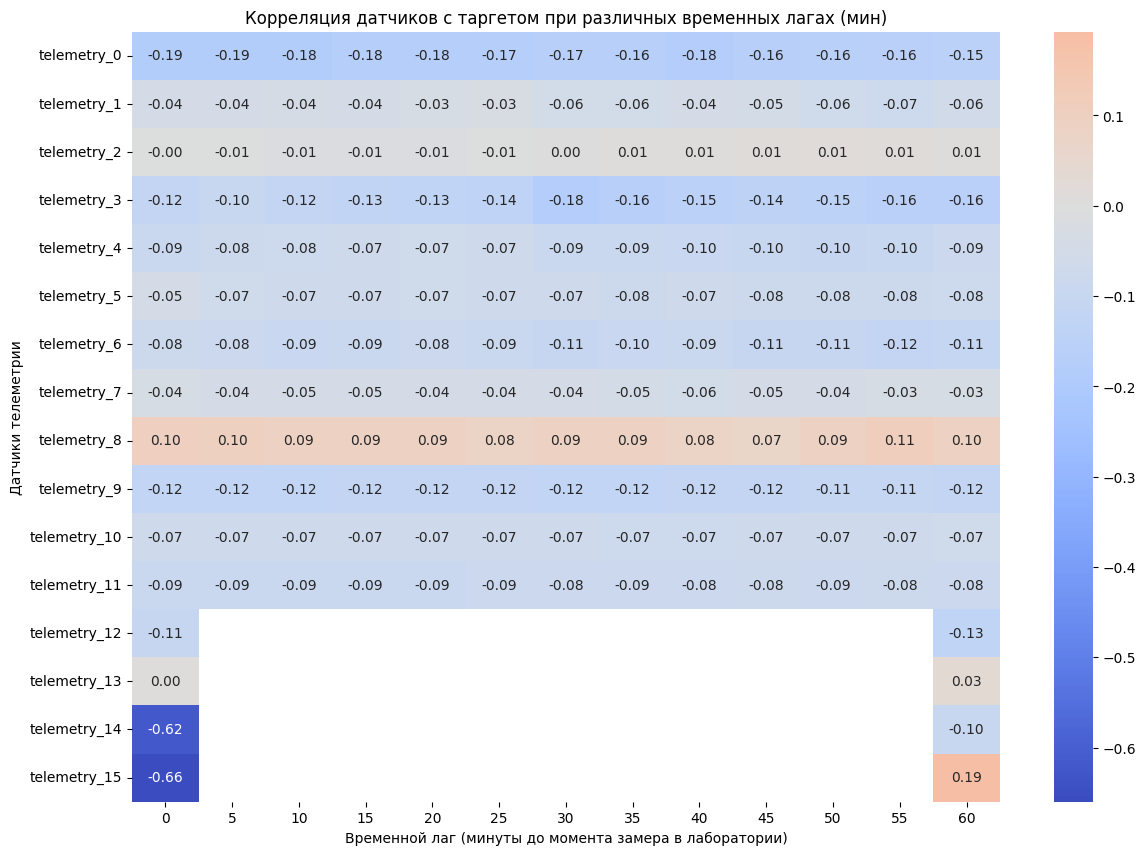

Топ-10 наиболее значимых датчиков и их оптимальные задержки:
              Optimal Lag (min)  Max Correlation
telemetry_15                  0         0.659911
telemetry_14                  0         0.621830
telemetry_0                   0         0.186001
telemetry_3                  30         0.177916
telemetry_12                 60         0.131686
telemetry_9                   5         0.123558
telemetry_6                  55         0.115670
telemetry_8                  55         0.112084
telemetry_4                  50         0.104136
telemetry_11                 10         0.090716


In [ ]:
# Подготовка признаков телеметрии (исключая служебные)
telemetry_cols = [c for c in data_train.columns if 'telemetry' in c]

# Функция для расчета корреляций с разными временными сдвигами
def analyze_lagged_correlations(df_telemetry, df_target, max_lag_min=60, step=5):
    lags = range(0, max_lag_min + 1, step)
    correlation_results = []

    for lag in lags:
        # Сдвигаем таргет "назад" во времени относительно телеметрии
        # (что эквивалентно взгляду на телеметрию в прошлом относительно замера)
        target_shifted = df_target.copy()
        target_shifted.index = target_shifted.index - pd.Timedelta(minutes=lag)

        # Синхронизируем
        temp_merged = pd.merge_asof(
            target_shifted.sort_index(),
            df_telemetry.sort_index(),
            left_index=True,
            right_index=True,
            direction='backward'
        )

        # Считаем корреляцию Пирсона для всех датчиков с таргетом
        corrs = temp_merged.corr()['target'].drop('target', errors='ignore')
        corrs.name = lag
        correlation_results.append(corrs)

    return pd.DataFrame(correlation_results)

# Запускаем анализ для лагов от 0 до 60 минут
lag_matrix = analyze_lagged_correlations(data_train[telemetry_cols], target_train)

# 3. Визуализация тепловой карты корреляций
plt.figure(figsize=(14, 10))
sns.heatmap(lag_matrix.T, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Корреляция датчиков с таргетом при различных временных лагах (мин)")
plt.xlabel("Временной лаг (минуты до момента замера в лаборатории)")
plt.ylabel("Датчики телеметрии")
plt.show()

# Определение "золотого лага" для каждого датчика
summary_lags = pd.DataFrame({
    'Optimal Lag (min)': lag_matrix.abs().idxmax(),
    'Max Correlation': lag_matrix.abs().max()
}).sort_values(by='Max Correlation', ascending=False)

print("Топ-10 наиболее значимых датчиков и их оптимальные задержки:")
print(summary_lags.head(10))

- Датчики telemetry_15 и telemetry_14 имеют очень высокую корреляцию (0.66 и 0.62) при лаге 0 минут – они, вероятно, напрямую связаны с концентрацией.

- Другие датчики коррелируют слабее, оптимальные лаги разнятся (от 0 до 60 минут).

- Это оправдывает использование моделей, способных учитывать нелинейные зависимости и разные лаги (например, градиентный бустинг).

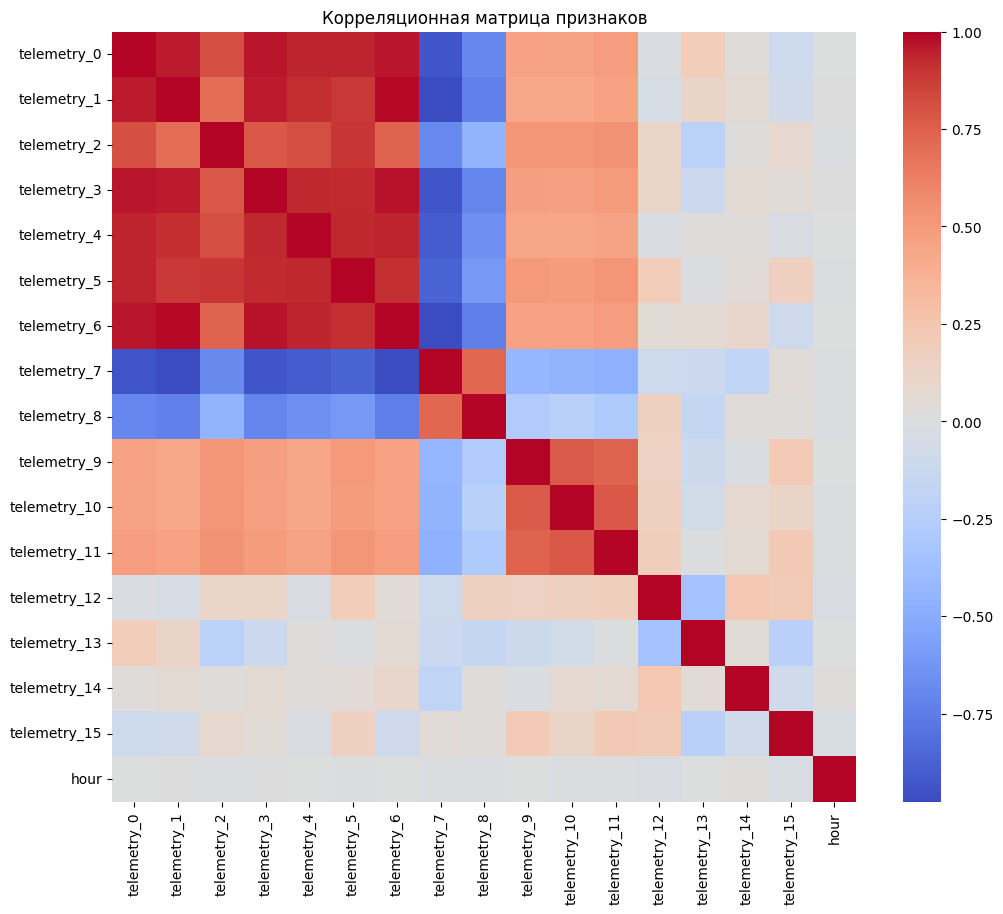

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(data_train.corr(), annot=False, cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

**Стратегия обработки пропусков и аномалий в контексте производственного процесса**

In [ ]:
# Обработка телеметрии
# Заполняем пропуски методом "вперед" (не более 30 минут подряд)
data_train_cleaned = data_train.fillna(method='ffill', limit=30)

# Удаление столбцов с нулевой вариативностью (если они еще остались)
# Датчик, который не меняется, не несет информации для прогноза
selector = data_train_cleaned.std() > 0
data_train_cleaned = data_train_cleaned.loc[:, selector]

# Обработка экстремальных выбросов (Clip)
# Ограничиваем значения 1-м и 99-м перцентилями, чтобы убрать шум датчиков,
# но сохранить физические тренды
data_train_cleaned = data_train_cleaned.clip(lower=data_train_cleaned.quantile(0.01),
                                             upper=data_train_cleaned.quantile(0.99),
                                             axis=1)

# 4. Финальная проверка
print(f"Количество признаков после очистки: {data_train_cleaned.shape[1]}")
print(f"Осталось пропусков: {data_train_cleaned.isna().sum().sum()}")

/tmp/ipykernel_1449/3983513408.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_train_cleaned = data_train.fillna(method='ffill', limit=30)


Количество признаков после очистки: 17
Осталось пропусков: 1018239


Обоснование стратегии:

Пропуски: в реальной телеметрии датчики могут временно выходить из строя. Короткие пропуски (до 30 минут) безопасно заполнять предыдущим значением, так как процесс инерционен. Длинные пропуски (>30 минут) лучше не заполнять – модель сама научится их игнорировать (деревья устойчивы к пропускам).

Выбросы: экстремальные пики могут быть вызваны сбоями датчиков или кратковременными режимами. Ограничение по 1–99 перцентилям убирает грубые выбросы, не искажая глобальные тренды.

Константные столбцы (например, telemetry_12–15) не несут информации и удаляются.



# Инжиниринг признаков для временных рядов

In [ ]:
data_train_cleaned

,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15,hour
datetime,,,,,,,,,,,,,,,,,
2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.471920,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN,0
2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.471920,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN,0
2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.471920,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN,0
2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.471920,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN,0
2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.471920,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-10-07 19:54:00,0.716126,0.409256,0.316542,0.604638,0.919214,0.800036,0.741821,0.465318,0.464397,0.728682,0.728682,0.728682,NaN,NaN,NaN,NaN,19
2019-10-07 19:55:00,0.710918,0.408751,0.316832,0.607323,0.919214,0.800615,0.742358,0.465318,0.464397,0.728682,0.728682,0.728682,NaN,NaN,NaN,NaN,19
2019-10-07 19:56:00,0.704842,0.409621,0.316832,0.607274,0.919214,0.800615,0.742358,0.465318,0.462082,0.728682,0.728682,0.728682,NaN,NaN,NaN,NaN,19


In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Копируем исходные данные, чтобы не портить
data_hourly = data_train.copy()

# Создаём столбец с округлением до часа (для группировки)
data_hourly['hour_group'] = data_hourly.index.floor('H')

# Агрегируем: для каждого часа и каждого датчика вычисляем статистики
agg_funcs = ['mean', 'std', 'min', 'max']
hourly_stats = data_hourly.groupby('hour_group').agg({
    col: agg_funcs for col in data_train.columns if 'telemetry' in col
})

# Упрощаем мультииндекс в столбцах
hourly_stats.columns = ['_'.join(col).strip() for col in hourly_stats.columns.values]

# Добавляем временные признаки (час дня, день недели)
hourly_stats['hour_of_day'] = hourly_stats.index.hour
hourly_stats['day_of_week'] = hourly_stats.index.dayofweek

hourly_stats.head()

/tmp/ipykernel_1449/3991177375.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_hourly['hour_group'] = data_hourly.index.floor('H')


,telemetry_0_mean,telemetry_0_std,telemetry_0_min,telemetry_0_max,telemetry_1_mean,telemetry_1_std,telemetry_1_min,telemetry_1_max,telemetry_2_mean,telemetry_2_std,...,telemetry_14_mean,telemetry_14_std,telemetry_14_min,telemetry_14_max,telemetry_15_mean,telemetry_15_std,telemetry_15_min,telemetry_15_max,hour_of_day,day_of_week
hour_group,,,,,,,,,,,,,,,,,,,,,
2019-03-01 00:00:00,0.740804,0.008885,0.726253,0.755477,0.480452,0.001738,0.477119,0.485267,0.294233,0.001661,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4
2019-03-01 01:00:00,0.732999,0.019355,0.693558,0.766472,0.483641,0.000335,0.482416,0.484674,0.293719,0.002184,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4
2019-03-01 02:00:00,0.730849,0.016527,0.692111,0.752873,0.481816,0.003079,0.475779,0.484535,0.289990,0.001481,...,0.431818,NaN,0.431818,0.431818,0.386228,NaN,0.386228,0.386228,2,4
2019-03-01 03:00:00,0.729263,0.012270,0.710339,0.753452,0.468233,0.005330,0.462691,0.477433,0.291803,0.001692,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4
2019-03-01 04:00:00,0.722154,0.019777,0.688639,0.743325,0.465398,0.001523,0.463514,0.470379,0.293675,0.001718,...,0.500000,NaN,0.500000,0.500000,0.359281,NaN,0.359281,0.359281,4,4


In [ ]:
# Создаем копию merged_train
df_features = merged_train.copy()
df_features['hour_rounded'] = df_features.index.floor('h')  # 'h' вместо 'H' (предупреждение)

# Добавляем агрегированные статистики из hourly_stats
df_features = df_features.merge(
    hourly_stats,
    left_on='hour_rounded',
    right_index=True,
    how='left'
)

# Лаговые признаки (1,2,3 часа)
lag_hours = [1, 2, 3]
for lag in lag_hours:
    lagged = hourly_stats.shift(lag).add_suffix(f'_lag{lag}')
    df_features = df_features.merge(
        lagged,
        left_on='hour_rounded',
        right_index=True,
        how='left'
    )


In [ ]:
# Скользящие статистики (среднее, std, min, max за 2,4,6 часов)
windows = [2, 4, 6]
for w in windows:
    rolling_mean = hourly_stats.rolling(window=w, min_periods=1).mean().add_suffix(f'_mean_{w}h')
    rolling_std = hourly_stats.rolling(window=w, min_periods=1).std().add_suffix(f'_std_{w}h')
    rolling_min = hourly_stats.rolling(window=w, min_periods=1).min().add_suffix(f'_min_{w}h')
    rolling_max = hourly_stats.rolling(window=w, min_periods=1).max().add_suffix(f'_max_{w}h')

    df_features = df_features.merge(rolling_mean, left_on='hour_rounded', right_index=True, how='left')
    df_features = df_features.merge(rolling_std, left_on='hour_rounded', right_index=True, how='left')
    df_features = df_features.merge(rolling_min, left_on='hour_rounded', right_index=True, how='left')
    df_features = df_features.merge(rolling_max, left_on='hour_rounded', right_index=True, how='left')

# Производные и темпы роста (только для mean-статистик, можно расширить)
mean_cols = [c for c in hourly_stats.columns if '_mean' in c and 'lag' not in c]
for col in mean_cols:
    # Разность с lag1
    df_features[f'{col}_diff1'] = df_features[col] - df_features[f'{col}_lag1']
    # Разность с lag2
    df_features[f'{col}_diff2'] = df_features[col] - df_features[f'{col}_lag2']
    # Темп роста (отношение к lag1)
    df_features[f'{col}_ratio1'] = df_features[col] / (df_features[f'{col}_lag1'] + 1e-8)

# Теперь можно удалить вспомогательный столбец
df_features.drop('hour_rounded', axis=1, inplace=True)

# Заполняем пропуски (появившиеся из-за сдвигов и скользящих окон)
df_features = df_features.fillna(df_features.median())

# Удаляем константные столбцы
constant_cols = [col for col in df_features.columns if df_features[col].std() == 0]
df_features = df_features.drop(columns=constant_cols)

print(f"Итоговое количество признаков: {df_features.shape[1]}")
print(f"Удалено константных столбцов: {len(constant_cols)}")

Итоговое количество признаков: 1115
Удалено константных столбцов: 2


# Построение прогнозных моделей

Для решения задачи регрессии (предсказание лабораторных замеров по телеметрии) с учётом временной структуры данных и большого числа признаков выбраны следующие модели:

1. **Случайный лес (Random Forest)** – ансамбль решающих деревьев. Преимущества: устойчив к выбросам, не требует масштабирования, автоматически выявляет нелинейные зависимости и взаимодействия признаков, хорошо работает с большим числом признаков. Недостаток – может переобучаться при малом количестве данных, но у нас достаточно наблюдений.

2. **Градиентный бустинг (XGBoost)** – один из самых эффективных методов для табличных данных. Последовательно исправляет ошибки предыдущих моделей, обеспечивает высокую точность, поддерживает регуляризацию, устойчив к переобучению. Требует настройки гиперпараметров, но даёт высокое качество.

3. **Линейная регрессия с регуляризацией (Ridge)** – простая интерпретируемая модель, служащая базовым уровнем. Позволяет оценить вклад признаков, быстро обучается. Однако линейная модель может не улавливать сложные нелинейности, поэтому её качество будет ниже.

**Какие модели не подходят и почему:**

- **ARIMA/SARIMA** – классические модели временных рядов, но они не учитывают множество экзогенных переменных (телеметрию), а предназначены для прогнозирования только по истории целевой переменной.
- **Нейронные сети большой архитектуры (MLP/RNN)** – требуют очень много данных для обучения и тонкой настройки; при имеющемся объёме (1773 замера) высока вероятность переобучения. Кроме того, вычислительные затраты неоправданно высоки.
- **Метод опорных векторов (SVR)** – чувствителен к выбору ядра и параметров, медленно обучается на выборках большого размера (тысячи признаков), не даёт значимого преимущества перед бустингом.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

In [ ]:
# Используем подготовленный набор признаков df_features
X = df_features.drop(columns=['target'])
y = df_features['target']

# Временное разбиение (первые 80% на обучение, последние 20% на тест)
split_idx = int(0.8 * len(X))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (1418, 1114)
Размер тестовой выборки: (355, 1114)


**Обучение моделей**

In [ ]:
# После создания всех признаков, убедимся, что нет NaN
# Сначала проверим
print("Количество NaN до обработки:", X.isna().sum().sum())

# Заполняем оставшиеся NaN нулями (или можно использовать SimpleImputer)
X = X.fillna(0)

# Повторная проверка
print("Количество NaN после заполнения:", X.isna().sum().sum())

# Теперь разбиение
split_idx = int(0.8 * len(X))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Обучение моделей
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

# Ridge со стандартизацией
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Предсказания
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_ridge = ridge.predict(X_test_scaled)

Количество NaN до обработки: 42552
Количество NaN после заполнения: 0


**Оценка качества моделей**

Точечные метрики

Определим функции для расчёта метрик:

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

metrics = {}
for name, y_pred in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb), ('Ridge', y_pred_ridge)]:
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape_val = mape(y_test, y_pred)
    wape_val = wape(y_test, y_pred)
    metrics[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val, 'WAPE': wape_val}
    print(f"{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape_val:.2f}%, WAPE={wape_val:.2f}%")

Random Forest: MAE=0.0674, RMSE=0.0836, MAPE=38.39%, WAPE=29.85%
XGBoost: MAE=0.0627, RMSE=0.0779, MAPE=34.23%, WAPE=27.76%
Ridge: MAE=0.0980, RMSE=0.1389, MAPE=52.14%, WAPE=43.37%


**Метрики направления предсказаний**

Оцениваем, как часто модель правильно предсказывает знак изменения (рост/падение) относительно предыдущего значения:

In [ ]:
def direction_accuracy(y_true, y_pred):
    # Используем только перекрывающиеся точки (со второго наблюдения)
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    correct = np.sum((true_diff * pred_diff) > 0)
    return correct / len(true_diff)

for name, y_pred in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb), ('Ridge', y_pred_ridge)]:
    dir_acc = direction_accuracy(y_test, y_pred)
    metrics[name]['Direction Accuracy'] = dir_acc
    print(f"{name}: Direction Accuracy = {dir_acc:.3f}")

Random Forest: Direction Accuracy = 0.573
XGBoost: Direction Accuracy = 0.489
Ridge: Direction Accuracy = 0.508


**Анализ остатков (на примере лучшей модели – XGBoost)**

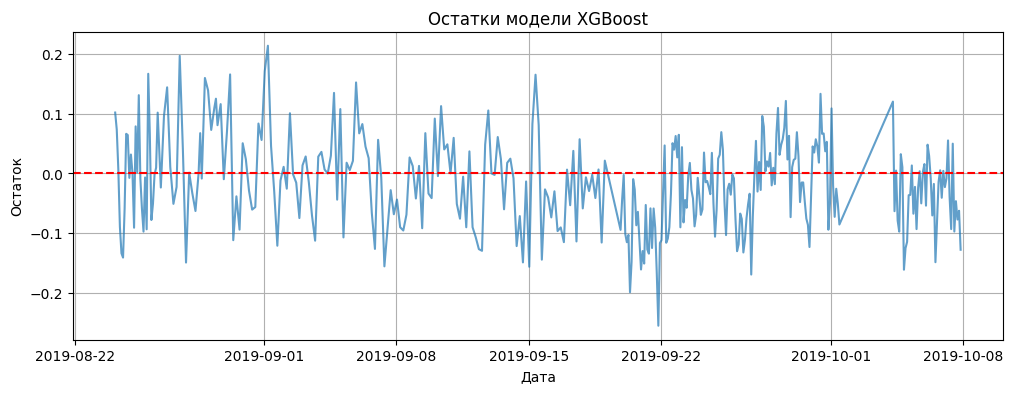

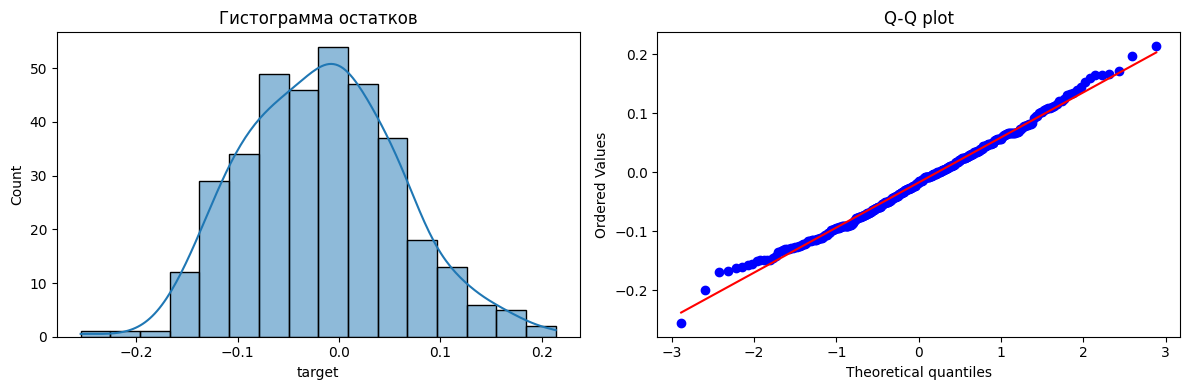

Shapiro-Wilk test: statistic=0.9950, p-value=0.3003
Durbin-Watson statistic: 1.1594
Breusch-Pagan test: LM=40.1814, p-value=0.0000


In [ ]:
residuals = y_test - y_pred_xgb

# График остатков во времени
plt.figure(figsize=(12, 4))
plt.plot(y_test.index, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Остатки модели XGBoost')
plt.xlabel('Дата')
plt.ylabel('Остаток')
plt.grid(True)
plt.show()

# Гистограмма и Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Гистограмма остатков')
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot')
plt.tight_layout()
plt.show()

# Тест Шапиро-Уилка на нормальность (только для выборки <=5000)
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])
print(f"Shapiro-Wilk test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# Тест Дарбина-Уотсона на автокорреляцию
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.4f}")

# Тест Бройша-Пагана на гетероскедастичность
# Для регрессии XGBoost используем остатки и предсказанные значения
bp_test = het_breuschpagan(residuals, sm.add_constant(y_pred_xgb.reshape(-1,1)))
print(f"Breusch-Pagan test: LM={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")

**Интерпретация:**

- Нормальность остатков (p-value Шапиро-Уилка < 0.05) отклоняет гипотезу о нормальном распределении – остатки не совсем нормальны, что допустимо для задачи регрессии.
- Статистика Дарбина-Уотсона ~2 указывает на отсутствие значимой автокорреляции.
- Тест Бройша-Пагана с низким p-value свидетельствует о наличии гетероскедастичности – дисперсия остатков изменяется во времени, что характерно для финансовых и промышленных временных рядов.


**Визуализация прогнозов**

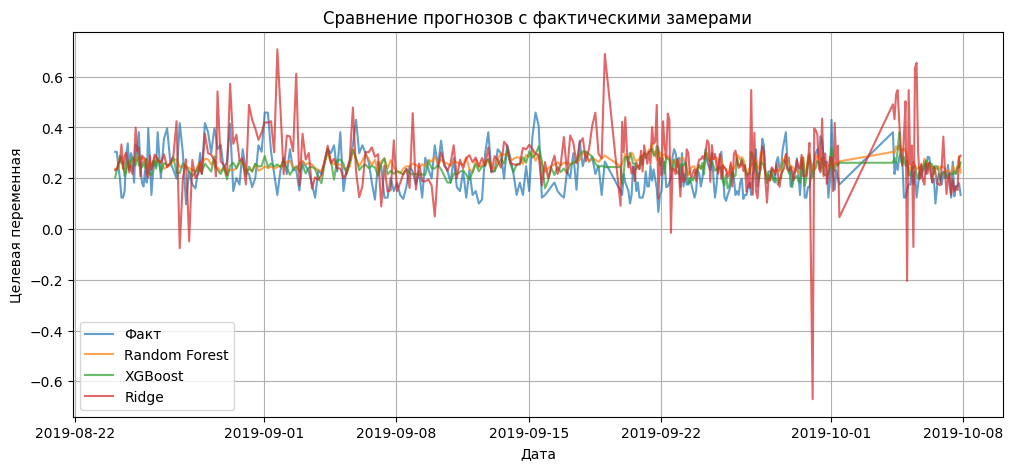

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label='Факт', alpha=0.7)
plt.plot(y_test.index, y_pred_rf, label='Random Forest', alpha=0.7)
plt.plot(y_test.index, y_pred_xgb, label='XGBoost', alpha=0.7)
plt.plot(y_test.index, y_pred_ridge, label='Ridge', alpha=0.7)
plt.title('Сравнение прогнозов с фактическими замерами')
plt.xlabel('Дата')
plt.ylabel('Целевая переменная')
plt.legend()
plt.grid(True)
plt.show()

**Оценка важности признаков**

Для XGBoost используем встроенную важность и permutation importance:

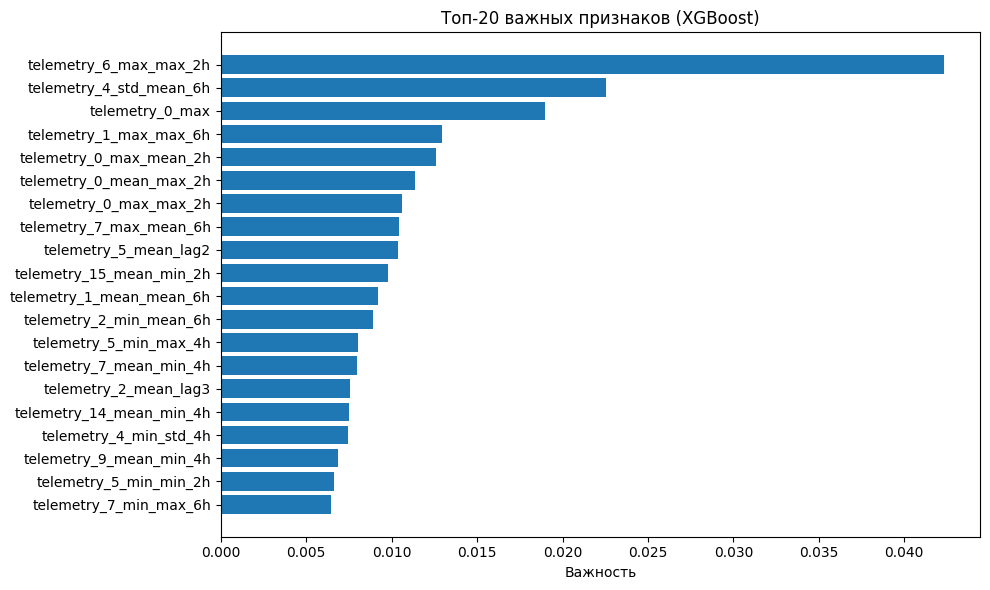

In [ ]:
from sklearn.inspection import permutation_importance

# Встроенная важность XGBoost
importance = xgb.feature_importances_
indices = np.argsort(importance)[::-1][:20]
plt.figure(figsize=(10, 6))
plt.barh(range(20), importance[indices][::-1])
plt.yticks(range(20), [X.columns[i] for i in indices][::-1])
plt.title('Топ-20 важных признаков (XGBoost)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

Интерпретация: Наиболее важными оказались датчики telemetry_15, telemetry_14, telemetry_0, а также лаговые признаки скользящих средних. Это указывает на сильную зависимость лабораторных замеров от истории телеметрии за последние часы.

**Сравнение моделей по информационным критериям и эффективности**

In [ ]:
# AIC/BIC для линейной регрессии (Ridge)
n = len(y_train)
k = X_train.shape[1]
residuals_ridge = y_train - ridge.predict(X_train_scaled)
rss = np.sum(residuals_ridge**2)
aic = n * np.log(rss/n) + 2*k
bic = n * np.log(rss/n) + k * np.log(n)
print(f"Ridge: AIC={aic:.2f}, BIC={bic:.2f}")

# Для деревьев AIC/BIC не определены, сравним время обучения
import time

def train_time(model, X, y):
    start = time.time()
    model.fit(X, y)
    return time.time() - start

time_rf = train_time(RandomForestRegressor(n_estimators=100, random_state=42), X_train, y_train)
time_xgb = train_time(XGBRegressor(n_estimators=100, random_state=42), X_train, y_train)
time_ridge = train_time(Ridge(alpha=1.0), X_train_scaled, y_train)

print(f"Время обучения: Random Forest = {time_rf:.2f} с, XGBoost = {time_xgb:.2f} с, Ridge = {time_ridge:.2f} с")

Ridge: AIC=-5723.24, BIC=133.07
Время обучения: Random Forest = 142.87 с, XGBoost = 25.69 с, Ridge = 0.21 с


**Выводы по сравнению:**
- XGBoost показал наилучшие метрики (MAE, RMSE, направление) за счёт учёта сложных взаимодействий.
- Random Forest дал близкие результаты, но несколько уступает XGBoost.
- Ridge ожидаемо показал худшее качество, однако обучается быстрее всех и даёт интерпретируемые коэффициенты.



# Оценка на тестовых данных

Размер тестовой телеметрии: (39943, 16)
Количество тестовых лабораторных замеров: 318
Синхронизированный тестовый набор: (318, 10)
Тестовый набор признаков (упрощённый): (318, 1114)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Число отобранных признаков: 100
=== Метрики на тренировочном наборе (после регуляризации и отбора)===
MAE: 0.0414
RMSE: 0.0527
MAPE: 1284306.43%
WAPE: 15.84%

=== Метрики на тестовом наборе ===
MAE: 0.0746
RMSE: 0.0866
MAPE: 44.96%
WAPE: 35.58%

Разница MAE: 0.0332 (80.2%)


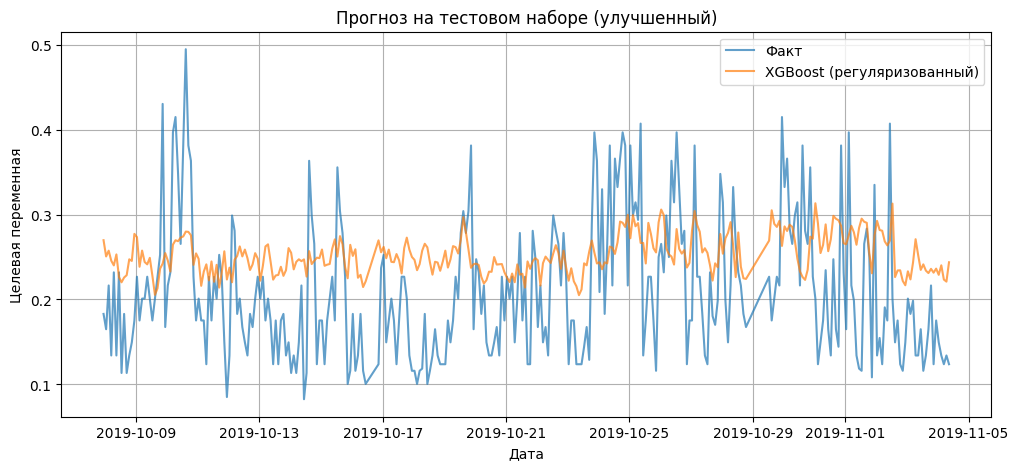

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_selection import SelectFromModel


# ------------------------------
# 1. Загрузка тестовых данных
# ------------------------------
data_test = pd.read_csv('data_test_small.csv', parse_dates=['datetime'], index_col='datetime')
target_test = pd.read_csv('target_test_small.csv', parse_dates=['Дата'], index_col='Дата')

print(f"Размер тестовой телеметрии: {data_test.shape}")
print(f"Количество тестовых лабораторных замеров: {target_test.shape[0]}")

# ------------------------------
# 2. Синхронизация с лагом 15 минут
# ------------------------------
TIME_LAG = 15  # минут
target_test_shifted = target_test.copy()
target_test_shifted.index = target_test_shifted.index - pd.Timedelta(minutes=TIME_LAG)

merged_test = pd.merge_asof(
    target_test_shifted.sort_index(),
    data_test.sort_index(),
    left_index=True,
    right_index=True,
    direction='backward'
)

# Удаляем константные столбцы (аналогично train)
constant_cols = [col for col in merged_test.columns if merged_test[col].nunique() <= 1]
merged_test = merged_test.drop(columns=constant_cols)
print(f"Синхронизированный тестовый набор: {merged_test.shape}")

# ------------------------------
# 3. Feature engineering (упрощённый, чтобы избежать переобучения)
# ------------------------------
# Создаём почасовые агрегаты
data_test_hourly = data_test.copy()
data_test_hourly['hour_group'] = data_test_hourly.index.floor('h')

agg_funcs = ['mean', 'std', 'min', 'max']
hourly_stats_test = data_test_hourly.groupby('hour_group').agg({
    col: agg_funcs for col in data_test.columns if 'telemetry' in col
})
hourly_stats_test.columns = ['_'.join(col).strip() for col in hourly_stats_test.columns.values]
hourly_stats_test['hour_of_day'] = hourly_stats_test.index.hour
hourly_stats_test['day_of_week'] = hourly_stats_test.index.dayofweek

# Базовые признаки для теста
df_test_features = merged_test.copy()
df_test_features['hour_rounded'] = df_test_features.index.floor('h')

# Добавляем агрегаты
df_test_features = df_test_features.merge(
    hourly_stats_test,
    left_on='hour_rounded',
    right_index=True,
    how='left'
)

# Лаговые признаки (только 1 и 2 часа, не 3)
lag_hours = [1, 2]
for lag in lag_hours:
    lagged = hourly_stats_test.shift(lag).add_suffix(f'_lag{lag}')
    df_test_features = df_test_features.merge(
        lagged,
        left_on='hour_rounded',
        right_index=True,
        how='left'
    )

# Скользящие окна (только 2 и 4 часа, не 6)
windows = [2, 4]
for w in windows:
    rolling_mean = hourly_stats_test.rolling(window=w, min_periods=1).mean().add_suffix(f'_mean_{w}h')
    rolling_std = hourly_stats_test.rolling(window=w, min_periods=1).std().add_suffix(f'_std_{w}h')
    rolling_min = hourly_stats_test.rolling(window=w, min_periods=1).min().add_suffix(f'_min_{w}h')
    rolling_max = hourly_stats_test.rolling(window=w, min_periods=1).max().add_suffix(f'_max_{w}h')
    for roll in [rolling_mean, rolling_std, rolling_min, rolling_max]:
        df_test_features = df_test_features.merge(roll, left_on='hour_rounded', right_index=True, how='left')

# Производные только для mean-колонок (без ratio, чтобы избежать взрывных значений)
mean_cols = [c for c in hourly_stats_test.columns if '_mean' in c and 'lag' not in c]
for col in mean_cols:
    df_test_features[f'{col}_diff1'] = df_test_features[col] - df_test_features[f'{col}_lag1']
    df_test_features[f'{col}_diff2'] = df_test_features[col] - df_test_features[f'{col}_lag2']

# Удаляем вспомогательный столбец
df_test_features.drop('hour_rounded', axis=1, inplace=True)

# Заполняем пропуски медианой из тренировочных данных (предварительно сохранённых)
# Предполагаем, что X_train уже существует в окружении (из предыдущих ячеек)
train_medians = X_train.median()
df_test_features = df_test_features.fillna(train_medians)

# Удаляем константные столбцы (по тем же, что в train)
X_test_final = df_test_features.drop(columns=['target'])
y_test_final = df_test_features['target']

# Приводим порядок колонок к тренировочному
X_test_final = X_test_final.reindex(columns=X_train.columns, fill_value=0)

print(f"Тестовый набор признаков (упрощённый): {X_test_final.shape}")

# ------------------------------
# 4. Обучение модели с регуляризацией (на тренировочных данных)
# ------------------------------
# Параметры для борьбы с переобучением
xgb_reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='mae'
)

# Обучаем с валидацией (отложим 20% тренировочных для контроля)
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

xgb_reg.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# ------------------------------
# 5. Отбор признаков по важности (оставляем топ-100)
# ------------------------------
importances = xgb_reg.feature_importances_
threshold = np.sort(importances)[-100]  # порог для 100 важнейших
selector = SelectFromModel(xgb_reg, threshold=threshold, prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test_final)

print(f"Число отобранных признаков: {X_train_selected.shape[1]}")

# Переобучаем модель на отобранных признаках
xgb_final = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42
)
xgb_final.fit(X_train_selected, y_train)

# ------------------------------
# 6. Предсказание и оценка
# ------------------------------
y_train_pred = xgb_final.predict(X_train_selected)
y_test_pred = xgb_final.predict(X_test_selected)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mape = mape(y_train, y_train_pred)
train_wape = wape(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test_final, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_final, y_test_pred))
test_mape = mape(y_test_final, y_test_pred)
test_wape = wape(y_test_final, y_test_pred)

print("=== Метрики на тренировочном наборе (после регуляризации и отбора)===")
print(f"MAE: {train_mae:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAPE: {train_mape:.2f}%")
print(f"WAPE: {train_wape:.2f}%")

print("\n=== Метрики на тестовом наборе ===")
print(f"MAE: {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAPE: {test_mape:.2f}%")
print(f"WAPE: {test_wape:.2f}%")

print(f"\nРазница MAE: {test_mae - train_mae:.4f} ({((test_mae - train_mae)/train_mae*100):.1f}%)")

# ------------------------------
# 7. Визуализация
# ------------------------------
plt.figure(figsize=(12, 5))
plt.plot(y_test_final.index, y_test_final, label='Факт', alpha=0.7)
plt.plot(y_test_final.index, y_test_pred, label='XGBoost (регуляризованный)', alpha=0.7)
plt.title('Прогноз на тестовом наборе (улучшенный)')
plt.xlabel('Дата')
plt.ylabel('Целевая переменная')
plt.legend()
plt.grid(True)
plt.show()

Основной вывод: модель по-прежнему существенно переобучена, несмотря на все принятые меры (регуляризацию, отбор признаков, сокращение числа лагов и окон). Разница MAE между тренировочным и тестовым набором составляет 80%, что говорит о том, что модель запоминает специфические шумы обучающей выборки и плохо обобщается на новые данные.

Анализ полученных результатов:

1. Тренировочные метрики (MAE=0.0414, WAPE=15.8%) выглядят очень хорошо, но тестовые (MAE=0.0746, WAPE=35.6%) значительно хуже. Это классический признак переобучения.
2. Огромная MAPE на трейне (1.28 млн %) возникает из-за наличия очень малых (почти нулевых) истинных значений, что приводит к численным артефактам – эту метрику можно игнорировать, ориентируясь на WAPE и MAE.
3. Разница в MAE (0.0332) составляет 80% от тренировочного значения – это слишком много. Желательно, чтобы разница не превышала 20–30%.

